# Pair Stats Threshold Tuning

This notebook helps choose:
- `divergence_range_min`
- `divergence_std_min`
- `max_pairs_per_abstract`

It recreates `pair_stats` from merged affinity outputs and shows simple distributions and selection counts.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

repo_root = Path.cwd().resolve()
if not (repo_root / 'scripts').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from scripts.run_affinity_adjudication import (
    compute_pair_stats,
    normalize_abstract_index,
 )
sns.set_theme()
# pd.set_option('display.max_columns', 200)
# pd.set_option('display.width', 180)
# sns.set_theme(style='whitegrid')

In [2]:
# Find latest benchmark run directory

repo_root = Path.cwd().parent.resolve()
benchmark_root = repo_root / 'data' / 'results' / 'affinity_benchmark'

run_dirs = sorted([p for p in benchmark_root.iterdir() if p.is_dir()])
if not run_dirs:
    raise FileNotFoundError(f'No run dirs under: {benchmark_root}')

run_dir = run_dirs[-1]
run_dir

PosixPath('/mnt/c/Users/pgallego/OneDrive - Imperial College London/PhD/Repositories/article-classifier/data/results/affinity_benchmark/20260422_212121')

In [3]:
def affinity_level_fixed(score):
    if pd.isna(score):
        return pd.NA
    try:
        x = float(score)
    except Exception:
        return pd.NA
    if 0 <= x <= 40:
        return 'Low'
    if 40 < x <= 70:
        return 'Moderate'
    if 70 < x <= 100:
        return 'High'
    return pd.NA

In [4]:
def _compute_pair_stats(merged_df: pd.DataFrame, target_id_col: str, target_text_col: str, other_cols: list = None) -> pd.DataFrame:
    """Compute pair-level statistics from merged affinity DataFrame."""
    base_cols = [
        "Abstract_Index",
        "Abstract_Index_Norm",
        "Document Title",
        target_id_col,
        target_text_col,
    ]
    if other_cols:
        base_cols.extend(other_cols)

    grouped = (
        merged_df.groupby(base_cols, dropna=False, as_index=False)
        .agg(
            n_models=("Model_Slug", "nunique"),
            affinity_mean=("LLM_Affinity", "mean"),
            affinity_std=("LLM_Affinity", "std"),
            affinity_min=("LLM_Affinity", "min"),
            affinity_max=("LLM_Affinity", "max"),
            n_affinity_levels=("affinity_level", "nunique"),
        )
    )

    n_models_total = (
        merged_df.groupby(["Abstract_Index", "Abstract_Index_Norm", "Document Title", target_id_col])['Model_Slug']
        .nunique()
        .rename('n_models_total')
        .reset_index()
    )
    grouped = grouped.merge(
        n_models_total,
        on=["Abstract_Index",
            "Abstract_Index_Norm",
            "Document Title",
            target_id_col],
        how='left',
    )

    grouped["affinity_std"] = grouped["affinity_std"].fillna(0.0)
    grouped["affinity_range"] = grouped["affinity_max"] - grouped["affinity_min"]
    grouped['agreement_ratio'] = grouped['n_models'] / grouped['n_models_total']
    return grouped

In [5]:
def load_and_build(mode, other_cols=[]):
    if mode.lower() == 'prp':
        path = run_dir / 'merged_prp_affinities.csv'
        df = pd.read_csv(path)
        print(df['Model_Slug'].unique())
        df['LLM_Affinity'] = pd.to_numeric(df['LLM_Affinity'], errors='coerce')
        df = df[df['LLM_Affinity'].notna()].copy()
        df['Abstract_Index_Norm'] = df['Abstract_Index'].apply(normalize_abstract_index)
        if 'Document Title' not in df.columns:
            df['Document Title'] = ''
        if 'PRP_Description' not in df.columns:
            df['PRP_Description'] = df['PRP_Name'].astype(str)
        df['affinity_level'] = df['LLM_Affinity'].apply(affinity_level_fixed)
        return _compute_pair_stats(df, target_id_col='PRP_Name', target_text_col='PRP_Description', other_cols=other_cols)

    if mode.lower() == 'ra':
        path = run_dir / 'merged_ra_affinities.csv'
        df = pd.read_csv(path)
        df['LLM_Affinity'] = pd.to_numeric(df['LLM_Affinity'], errors='coerce')
        df = df[df['LLM_Affinity'].notna()].copy()
        df['Abstract_Index_Norm'] = df['Abstract_Index'].apply(normalize_abstract_index)
        if 'Document Title' not in df.columns:
            df['Document Title'] = ''
        if 'RA_Question' not in df.columns:
            df['RA_Question'] = df['RA2025_ID'].astype(str)
        df['affinity_level'] = df['LLM_Affinity'].apply(affinity_level_fixed)
        return _compute_pair_stats(df, target_id_col='RA2025_ID', target_text_col='RA_Question', other_cols=other_cols)

    raise ValueError('mode must be prp or ra')

In [6]:
df = pd.read_csv( run_dir / 'merged_prp_affinities.csv')
df[['Model_Slug', 'Abstract_Index']].drop_duplicates().groupby('Model_Slug').size()

Model_Slug
gemini-3.1-flash-lite-preview    100
gemma4-31b-cloud                 100
gpt-5.4                          100
gpt-5.4-mini                     100
ministral-3-14b-cloud            100
mistral-large-3-675b-cloud       100
dtype: int64

In [19]:
MODE = 'ra'  # change to 'ra' to inspect RA
VAR_Y = 'PRP_Name' if MODE == 'prp' else 'RA2025_ID'
MIN_MODELS = 2

pair_stats = load_and_build(MODE, ['affinity_level'])
# pair_stats = pair_stats[pair_stats['n_models'] >= MIN_MODELS].copy()

print(f'Mode: {MODE.upper()}')
print(f'Overall Agreement Level: {pair_stats.groupby(["Abstract_Index", VAR_Y])["agreement_ratio"].mean().describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])}')
# print(f'Pairs after n_models >= {MIN_MODELS}: {len(pair_stats):,}')
pair_stats[['affinity_range', 'affinity_std']].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

Mode: RA
Overall Agreement Level: count    4800.000000
mean        0.827222
std         0.249163
min         0.333333
50%         1.000000
75%         1.000000
90%         1.000000
95%         1.000000
99%         1.000000
max         1.000000
Name: agreement_ratio, dtype: float64


,affinity_range,affinity_std
count,6618.000000,6618.000000
mean,17.454518,7.853877
std,13.191609,5.729380
min,0.000000,0.000000
50%,20.000000,8.164966
75%,30.000000,12.377399
90%,40.000000,15.491933
95%,40.000000,16.793600
99%,40.000000,19.748418
max,40.000000,28.284271


In [20]:
pair_stats.head(10)

,Abstract_Index,Abstract_Index_Norm,Document Title,RA2025_ID,RA_Question,affinity_level,n_models,affinity_mean,affinity_std,affinity_min,affinity_max,n_affinity_levels,n_models_total,affinity_range,agreement_ratio
0,1,1,Scenario Reduction Network Based on Wasserstei...,1,what is the future of active power balance as ...,Low,6,6.666667,8.164966,0.0,20.0,1,6,20.0,1.000000
1,1,1,Scenario Reduction Network Based on Wasserstei...,2,how will protection systems need to change to ...,Low,6,5.833333,8.010410,0.0,20.0,1,6,20.0,1.000000
2,1,1,Scenario Reduction Network Based on Wasserstei...,3,how could the ibr control paradigm change from...,Low,6,7.500000,8.803408,0.0,20.0,1,6,20.0,1.000000
3,1,1,Scenario Reduction Network Based on Wasserstei...,4,what are the appropriate inverter capabilities...,Low,6,8.333333,9.831921,0.0,20.0,1,6,20.0,1.000000
4,1,1,Scenario Reduction Network Based on Wasserstei...,5,what recommendations for standard ibr frequenc...,Low,6,6.666667,8.164966,0.0,20.0,1,6,20.0,1.000000
5,1,1,Scenario Reduction Network Based on Wasserstei...,6,what requirements (e.g. impedance) should be p...,Low,6,5.833333,8.010410,0.0,20.0,1,6,20.0,1.000000
6,1,1,Scenario Reduction Network Based on Wasserstei...,7,what approaches can be taken to track the dyna...,Low,6,9.166667,12.006942,0.0,30.0,1,6,30.0,1.000000
7,1,1,Scenario Reduction Network Based on Wasserstei...,8,"what methods, including data types, and analys...",Low,6,8.333333,11.690452,0.0,30.0,1,6,30.0,1.000000
8,1,1,Scenario Reduction Network Based on Wasserstei...,9,what analytical tools and models should be pro...,High,1,75.000000,0.000000,75.0,75.0,1,6,0.0,0.166667
9,1,1,Scenario Reduction Network Based on Wasserstei...,9,what analytical tools and models should be pro...,Low,4,23.000000,11.944315,12.0,40.0,1,6,28.0,0.666667


<Axes: xlabel='agreement_ratio', ylabel='affinity_std'>

/home/pabloncho/.virtualenvs/classifier/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/pabloncho/.virtualenvs/classifier/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


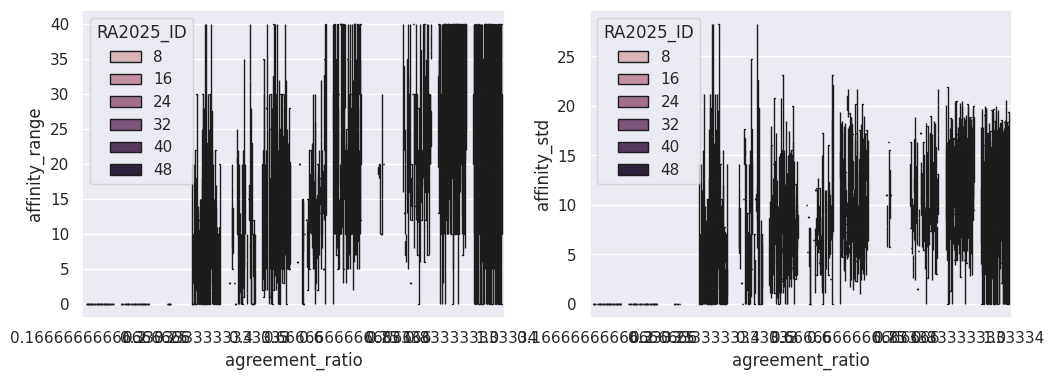

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)
sns.boxplot(
    data=pair_stats,
    hue=VAR_Y,
    y='affinity_range',
    ax=axes[0],
    x='agreement_ratio',
    showfliers=False,
 )
sns.boxplot(
    data=pair_stats,
    hue=VAR_Y,
    y='affinity_std',
    ax=axes[1],
    x='agreement_ratio',
    showfliers=False,
 )
# sns.catplot(
#     data=pair_stats,
#     hue="PRP_Name",
#     y='affinity_level',
#     ax=axes[2],
#     x='agreement_ratio',
#     # showfliers=False,
#  )


Coherence Level: 67.10%


np.float64(0.6710416666666666)

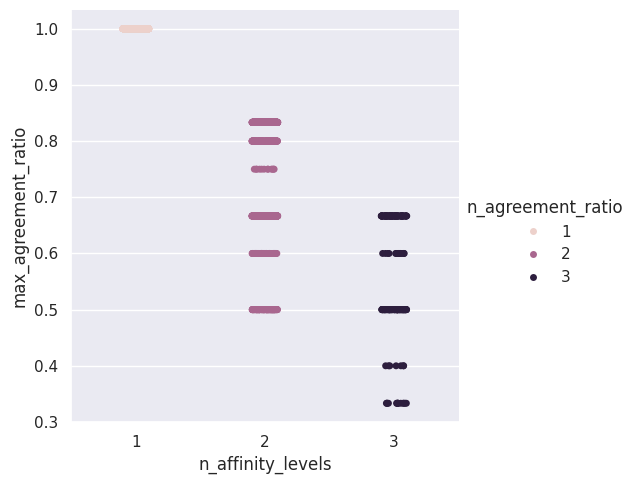

In [22]:
coherence_n_affinity_levels_aggrement_ratio = pair_stats.groupby(['Abstract_Index', VAR_Y], as_index=False).aggregate(
    n_affinity_levels=('affinity_level', "nunique"),
    avg_agreement_ratio=('agreement_ratio', "mean"),
    max_agreement_ratio=('agreement_ratio', "max"),
    n_agreement_ratio = ('agreement_ratio', "size")
)

sns.catplot(data=coherence_n_affinity_levels_aggrement_ratio, x="n_affinity_levels", hue="n_agreement_ratio", y="max_agreement_ratio")
coherence_level = (coherence_n_affinity_levels_aggrement_ratio['n_affinity_levels'] == 1).sum() / coherence_n_affinity_levels_aggrement_ratio['n_affinity_levels'].count()
print(f'Coherence Level: {coherence_level:.2%}')

# check

pair_stats_ = load_and_build(MODE)
(pair_stats_["n_affinity_levels"] == 1).sum() / pair_stats_["n_affinity_levels"].count()


In [23]:
 pair_stats_["n_affinity_levels"]

0       1
1       1
2       1
3       1
4       1
       ..
4795    1
4796    1
4797    1
4798    1
4799    1
Name: n_affinity_levels, Length: 4800, dtype: int64

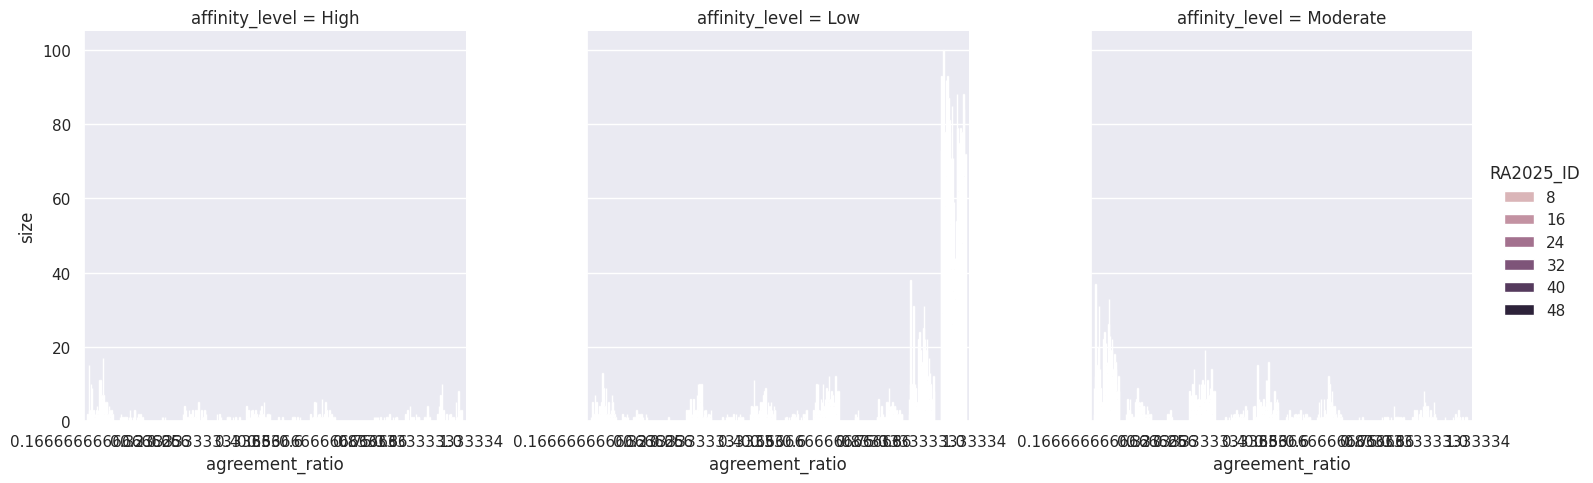

In [24]:
counts_abstracts_per_agreement = pair_stats.groupby([VAR_Y, 'affinity_level', 'agreement_ratio'], as_index=False).size()
sns.catplot(data=counts_abstracts_per_agreement, x="agreement_ratio", y="size", hue=VAR_Y, col='affinity_level',kind="bar")

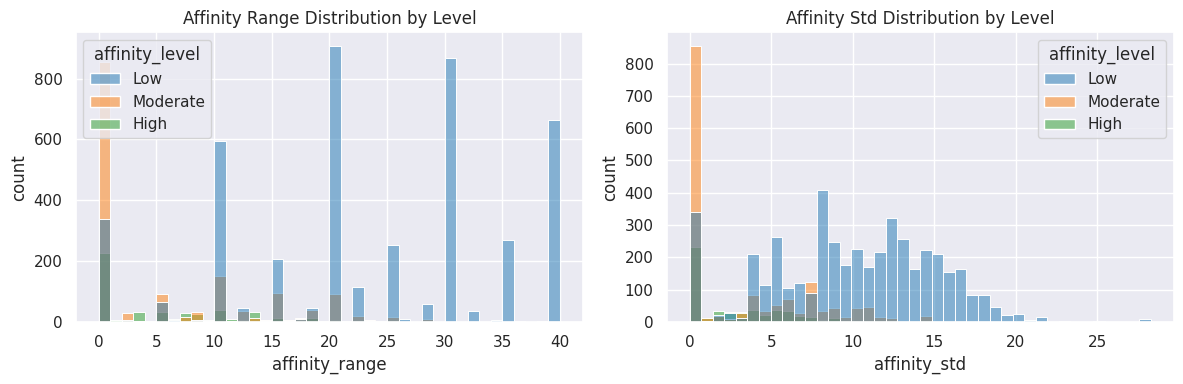

In [25]:
level_order = ['Low', 'Moderate', 'High']
level_colors = {'Low': '#1f77b4', 'Moderate': '#ff7f0e', 'High': '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

sns.histplot(
    data=pair_stats,
    x='affinity_range',
    hue='affinity_level',
    hue_order=level_order,
    palette=level_colors,
    bins=40,
    alpha=0.5,
    element='bars',
    stat='count',
    common_norm=False,
    ax=axes[0],
 )
axes[0].set_title('Affinity Range Distribution by Level')
axes[0].set_xlabel('affinity_range')
axes[0].set_ylabel('count')

sns.histplot(
    data=pair_stats,
    x='affinity_std',
    hue='affinity_level',
    hue_order=level_order,
    palette=level_colors,
    bins=40,
    alpha=0.5,
    element='bars',
    stat='count',
    common_norm=False,
    ax=axes[1],
 )
axes[1].set_title('Affinity Std Distribution by Level')
axes[1].set_xlabel('affinity_std')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

In [26]:

# sns.catplot(data=pair_stats, x="n_affinity_levels", y = )pair_stats


In [27]:
# Selection counts for candidate thresholds
range_grid = [10, 15, 20, 25, 30, 40]
std_grid = [5, 8, 10, 12, 15, 20]

rows = []
for r_min in range_grid:
    for s_min in std_grid:
        selected = (pair_stats['affinity_range'] >= r_min) | (pair_stats['affinity_std'] >= s_min)
        n_selected = int(selected.sum())
        pct = 100.0 * n_selected / len(pair_stats) if len(pair_stats) else 0.0
        rows.append({
            'divergence_range_min': r_min,
            'divergence_std_min': s_min,
            'selected_pairs': n_selected,
            'selected_pct': round(pct, 2),
        })

threshold_impact = pd.DataFrame(rows).sort_values(['selected_pairs', 'divergence_range_min', 'divergence_std_min'], ascending=[False, True, True])
threshold_impact.head(20)

,divergence_range_min,divergence_std_min,selected_pairs,selected_pct
0,10,5,4792,72.41
1,10,8,4768,72.05
2,10,10,4768,72.05
3,10,12,4768,72.05
4,10,15,4768,72.05
5,10,20,4768,72.05
6,15,5,4430,66.94
12,20,5,4430,66.94
18,25,5,4430,66.94
24,30,5,4430,66.94


In [28]:
# Simple guidance for max_pairs_per_abstract
RANGE_MIN = 25
STD_MIN = 12

selected = pair_stats[(pair_stats['affinity_range'] >= RANGE_MIN) | (pair_stats['affinity_std'] >= STD_MIN)].copy()
per_abstract = selected.groupby('Abstract_Index_Norm').size().rename('selected_pairs').reset_index()

print(f'Using divergence_range_min={RANGE_MIN}, divergence_std_min={STD_MIN}')
print(f'Abstracts with >=1 selected pair: {len(per_abstract):,}')
per_abstract['selected_pairs'].describe(percentiles=[0.5, 0.75, 0.9, 0.95])

Using divergence_range_min=25, divergence_std_min=12
Abstracts with >=1 selected pair: 100


count    100.000000
mean      22.950000
std        8.352554
min        4.000000
50%       23.000000
75%       27.000000
90%       31.100000
95%       36.050000
max       48.000000
Name: selected_pairs, dtype: float64

In [29]:
candidate_caps = [1, 2, 3, 4, 5, 6]
summary = []

for cap in candidate_caps:
    kept = per_abstract['selected_pairs'].clip(upper=cap).sum()
    dropped = per_abstract['selected_pairs'].sum() - kept
    summary.append({
        'max_pairs_per_abstract': cap,
        'kept_selected_pairs': int(kept),
        'dropped_due_to_cap': int(dropped),
    })

pd.DataFrame(summary)

,max_pairs_per_abstract,kept_selected_pairs,dropped_due_to_cap
0,1,100,2195
1,2,200,2095
2,3,300,1995
3,4,400,1895
4,5,499,1796
5,6,598,1697


## How to Use This

1. Set `MODE` to `prp` or `ra`.
2. Check distribution plots and quantiles for `affinity_range` and `affinity_std`.
3. Pick candidate `divergence_range_min` and `divergence_std_min` from the threshold impact table.
4. Use the cap table to pick `max_pairs_per_abstract` that balances review load vs coverage.